## מטרת העבודה

מטרת העבודה היא לבנות מודל לסיווג סנטימנט של ביקורות סרטים. המודל מקבל טקסט של ביקורת ומנסה לזהות את המחלקה המתאימה לה לפי עמודת `label`.

תהליך העבודה כולל טעינת הנתונים ובדיקתם, עיבוד מקדים של הטקסט, הפיכת הטקסט לייצוג מספרי באמצעות TF-IDF, אימון מודל Logistic Regression, בדיקת מספר שילובים של פרמטרים והערכת ביצועי המודל באמצעות Macro F1.

## חלק 1 – פרטי הסטודנטים

ליאור ג - 2894  
מור ע - 4859  
דניאל א - 4124  
גל י - 1252

## שימוש בכלי AI

במהלך העבודה נעשה שימוש בכלי AI לצורך סיוע בהבנת שלבי העבודה, בדיקת קוד ופתרון תקלות במהלך ההרצה.

דוגמה לשאלה שנשאלה:
> כיצד ניתן לבצע סיווג סנטימנט לטקסט באמצעות TF-IDF ו-Logistic Regression, ולהעריך את המודל באמצעות Macro F1?

הכלי שימש כאמצעי עזר, והקוד והתוצאות נבדקו במהלך העבודה במחברת.

## 1. הסבר על בעיית הלמידה וה-Dataset

העבודה עוסקת ב-**Sentiment Analysis**, משימה בתחום עיבוד שפה טבעית (NLP).

ה-Dataset כולל ביקורות על סרטים מ-IMDB. עמודת `text` מכילה את תוכן הביקורת, ועמודת `label` מכילה את המחלקה המתאימה לכל ביקורת.

זוהי בעיית **Classification**, שבה המטרה היא ללמוד את הקשר בין תוכן הביקורת לבין התווית שלה, ולאחר מכן לחזות את התווית עבור ביקורות שלא שימשו לאימון המודל.

In [1]:
# Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

## 2. טעינת הנתונים

הנתונים נטענים מתוך הקובץ `movie.csv`.

לאחר הטעינה מוצגות 5 השורות הראשונות כדי לוודא שהקובץ נטען בצורה תקינה ושעמודות הנתונים מופיעות במבנה הצפוי.

In [2]:
DATA_PATH = "movie.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset shape: (40000, 2)
Columns: ['text', 'label']


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


### בדיקת מבנה הנתונים

ה-Dataset כולל שתי עמודות עיקריות:

- `text` – הטקסט של ביקורת הסרט.
- `label` – התווית של הביקורת.

בנוסף נבדקים סוגי הנתונים, ערכים חסרים, רשומות כפולות והתפלגות המחלקות. בדיקות אלו מאפשרות להבין את מבנה הנתונים לפני תחילת תהליך האימון.

In [3]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB
None

Missing values:
text     0
label    0
dtype: int64

Duplicate rows: 277

Class distribution:
label
0    20019
1    19981
Name: count, dtype: int64
label
0    0.500475
1    0.499525
Name: proportion, dtype: float64


### משמעות עמודת `label`

בשלב זה נבדקים הערכים הייחודיים בעמודת `label` ומספר המחלקות הקיימות ב-Dataset.

בדיקה זו מאפשרת לזהות האם מדובר ב-Binary Classification או ב-Multi-Class Classification, ובהתאם לכך להעריך את ביצועי המודל באמצעות Macro F1.

In [4]:
unique_labels = sorted(df["label"].unique())
print("Unique label values:", unique_labels)
print("Number of classes:", len(unique_labels))

if len(unique_labels) == 2:
    print("This is a Binary Classification problem.")
else:
    print("This is a Multi-Class Classification problem.")

Unique label values: [np.int64(0), np.int64(1)]
Number of classes: 2
This is a Binary Classification problem.


## 3. יצירת Train Set ו-Test Set

ה-Dataset מחולק לשתי קבוצות: Train ו-Test.

נתוני ה-Train משמשים לאימון המודל, ואילו נתוני ה-Test נשמרים בנפרד ומשמשים להערכת ביצועי המודל על מידע שלא ראה בזמן האימון.

החלוקה מתבצעת באמצעות `stratify`, כדי לשמור ככל האפשר על אותה התפלגות של המחלקות בשתי הקבוצות.

In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nFirst 5 rows - TRAIN:")
display(train_df.head())

print("\nFirst 5 rows - TEST:")
display(test_df.head())

Train shape: (20000, 2)
Test shape: (20000, 2)

First 5 rows - TRAIN:


,text,label
0,"I liked how this started out, featuring some d...",0
1,This movie really starts strong. We know that ...,0
2,"I wasn't alive in the 60's, so I can't guarant...",1
3,This is a typical example of technically highl...,0
4,Masterpiece. Carrot Top blows the screen away....,0



First 5 rows - TEST:


,text,label
0,This movie makes me want to throw up every tim...,0
1,"I was drawn to this movie, curious to see how ...",0
2,This movie of 370 minutes was aired by the Ita...,1
3,The way i found out about this movie was when ...,1
4,"It's official, folks -- Hou Hsiao-Hsien doesn'...",0


## 4. הגדרת X ו-y

`X` מייצג את טקסט הביקורות שמשמש כקלט למודל.

`y` מייצג את התווית המתאימה לכל ביקורת.

נתוני ה-Test אינם משתתפים בתהליך האימון, כדי שניתן יהיה להעריך בסוף את יכולת ההכללה של המודל על נתונים חדשים.

In [6]:
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

## Feature Engineering

מודל למידת מכונה אינו יכול לעבוד ישירות עם טקסט חופשי, ולכן יש להמיר את הביקורות לייצוג מספרי.

תחילה מתבצע ניקוי בסיסי של הטקסט: המרה לאותיות קטנות, הסרת תגיות HTML, כתובות אינטרנט ותווים שאינם רלוונטיים, וכן איחוד של רווחים מיותרים.

לאחר הניקוי, הטקסט מיוצג באמצעות **TF-IDF**, שמעניק משקל לכל מילה בהתאם לחשיבות שלה בביקורת ביחס לשאר הביקורות.

בנוסף נבדקים גם **n-grams**, המאפשרים להתייחס לא רק למילים בודדות אלא גם לצירופים של מילים, וכך לשמור מידע נוסף על משמעות הטקסט.

לאחר מכן מוצגות מספר דוגמאות מתוך נתוני האימון והבדיקה לפני ואחרי תהליך הניקוי, כדי להמחיש את השינוי שבוצע בטקסט.

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)          # הסרת HTML
    text = re.sub(r"http\S+|www\.\S+", " ", text) # הסרת URLs
    text = re.sub(r"[^a-z\s']", " ", text)       # שמירת אותיות אנגליות ו-apostrophe
    text = re.sub(r"\s+", " ", text).strip()      # רווחים כפולים
    return text

In [8]:
examples_train = train_df["text"].head(3)
examples_test = test_df["text"].head(3)

print("TRAIN EXAMPLES")
for i, text in enumerate(examples_train, 1):
    print(f"\nExample {i}")
    print("Before:", text[:500])
    print("After :", clean_text(text)[:500])

print("\n" + "="*100)
print("TEST EXAMPLES")
for i, text in enumerate(examples_test, 1):
    print(f"\nExample {i}")
    print("Before:", text[:500])
    print("After :", clean_text(text)[:500])

TRAIN EXAMPLES

Example 1
Before: I liked how this started out, featuring some decent special-effects especially for a film 50 years old. There was some pretty impressive scenery. However, the film bogs down fairly early on with some very dumb dialog as the males all try to flirt with Anne Francis "Altaira Morbius.")<br /><br />Viewing this in the '90s after a long absence, it was fun to see Francis again, an actress who has done mostly television shows since this film was released....and is still acting. It also was interesting
After : i liked how this started out featuring some decent special effects especially for a film years old there was some pretty impressive scenery however the film bogs down fairly early on with some very dumb dialog as the males all try to flirt with anne francis altaira morbius viewing this in the ' s after a long absence it was fun to see francis again an actress who has done mostly television shows since this film was released and is still acting it also w

### TF-IDF

TF-IDF הוא ייצוג מספרי של טקסט שמעניק משקל גבוה יותר למילים שמאפיינות ביקורת מסוימת, ומשקל נמוך יותר למילים שמופיעות בתדירות גבוהה בביקורות רבות.

באמצעות השיטה ניתן להפוך כל ביקורת לווקטור מספרי שהמודל יכול לקבל כקלט, תוך שמירה על מידע לגבי המילים והביטויים המשמעותיים יותר בכל ביקורת.

In [9]:
demo_tfidf = TfidfVectorizer(
    preprocessor=clean_text,
    max_features=20,
    ngram_range=(1, 1)
)

demo_matrix = demo_tfidf.fit_transform(X_train.head(100))

print("TF-IDF matrix shape:", demo_matrix.shape)
print("Example feature names:")
print(demo_tfidf.get_feature_names_out()[:20])

demo_df = pd.DataFrame(
    demo_matrix[:3].toarray(),
    columns=demo_tfidf.get_feature_names_out()
)
display(demo_df)

TF-IDF matrix shape: (100, 20)
Example feature names:
['and' 'are' 'as' 'but' 'for' 'have' 'in' 'is' 'it' 'movie' 'not' 'of'
 'on' 'that' 'the' 'this' 'to' 'was' 'with' 'you']


,and,are,as,but,for,have,in,is,it,movie,not,of,on,that,the,this,to,was,with,you
0,0.155610,0.000000,0.074923,0.068098,0.137624,0.23226,0.114579,0.166804,0.264541,0.071775,0.072543,0.161905,0.213052,0.061463,0.457674,0.529082,0.264541,0.344060,0.134787,0.0
1,0.275139,0.084921,0.158968,0.000000,0.146002,0.00000,0.060777,0.412905,0.112258,0.228433,0.076960,0.114508,0.000000,0.326024,0.539486,0.336775,0.224517,0.073001,0.214489,0.0
2,0.287081,0.147678,0.276446,0.251263,0.000000,0.00000,0.211383,0.410311,0.097609,0.132415,0.000000,0.298694,0.000000,0.226783,0.469085,0.195218,0.292827,0.126949,0.124333,0.0


In [10]:
def build_model(C=1.0, max_features=10000, ngram_range=(1, 1)):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            preprocessor=clean_text,
            max_features=max_features,
            ngram_range=ngram_range
        )),
        ("classifier", LogisticRegression(
            C=C,
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

def train_model(model, X, y):
    model.fit(X, y)
    return model

def predict_model(model, X):
    return model.predict(X)

## חיפוש פרמטרים – Grid Search

כדי למצוא שילוב פרמטרים מתאים יותר נבדקים מספר ערכים עבור `max_features`, ‏`ngram_range` ו-`C`.

כל שילוב נבחן באמצעות **5-Fold Cross Validation**. נתוני האימון מחולקים לחמישה חלקים, ובכל סבב המודל מתאמן על ארבעה חלקים ונבדק על החלק שנותר.

התהליך חוזר חמש פעמים עבור כל שילוב, והציון הסופי של כל שילוב הוא ממוצע ציוני ה-Macro F1 שהתקבלו בחמש ההרצות.

בסיום נבחר שילוב הפרמטרים שקיבל את הציון הממוצע הגבוה ביותר.

In [11]:
baseline_model = build_model(
    C=1.0,
    max_features=10000,
    ngram_range=(1, 1)
)

baseline_model = train_model(baseline_model, X_train, y_train)

baseline_predictions = predict_model(baseline_model, X_test)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="macro"
)

print("Baseline Macro F1:", round(baseline_f1, 4))

Baseline Macro F1: 0.8861


## למה Macro F1?

מדד F1 משלב בין Precision לבין Recall.

ב-Macro F1 מחושב ציון F1 בנפרד לכל מחלקה, ולאחר מכן נלקח הממוצע בין המחלקות. בדרך זו כל מחלקה מקבלת משקל שווה במדד הסופי, ללא תלות בגודל שלה.

In [12]:
print(classification_report(y_test, baseline_predictions))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88     10010
           1       0.88      0.90      0.89      9990

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



In [13]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(preprocessor=clean_text)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "tfidf__max_features": [5000, 10000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "classifier__C": [0.5, 1.0, 2.0]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.5, 1.0, ...], 'tfidf__max_features': [5000, 10000], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


## 7. הצגת כל הפרמוטציות והתוצאות

תוצאות ה-Grid Search מוצגות ב-DataFrame שמרכז את כל שילובי הפרמטרים שנבדקו ואת ציון ה-Macro F1 הממוצע שהתקבל עבור כל שילוב.

כך ניתן להשוות בין כל האפשרויות ולזהות בצורה ברורה את שילוב הפרמטרים שהשיג את הביצועים הטובים ביותר.

In [14]:
results_df = pd.DataFrame(grid_search.cv_results_)

results_table = results_df[[
    "param_tfidf__max_features",
    "param_tfidf__ngram_range",
    "param_classifier__C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").reset_index(drop=True)

display(results_table)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest mean CV Macro F1:")
print(round(grid_search.best_score_, 4))

,param_tfidf__max_features,param_tfidf__ngram_range,param_classifier__C,mean_test_score,std_test_score,rank_test_score
0,10000,"(1, 2)",2.0,0.892442,0.001457,1
1,10000,"(1, 2)",1.0,0.890189,0.002395,2
2,10000,"(1, 1)",2.0,0.889440,0.003697,3
3,5000,"(1, 2)",2.0,0.888243,0.002629,4
4,5000,"(1, 1)",2.0,0.887037,0.002550,5
5,10000,"(1, 1)",1.0,0.885637,0.001772,6
6,5000,"(1, 2)",1.0,0.885490,0.002063,7
7,5000,"(1, 1)",1.0,0.883433,0.001982,8
8,10000,"(1, 2)",0.5,0.882887,0.002466,9
9,5000,"(1, 2)",0.5,0.880485,0.001752,10


Best parameters:
{'classifier__C': 2.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}

Best mean CV Macro F1:
0.8924


In [15]:
best_model = grid_search.best_estimator_

print(best_model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 preprocessor=<function clean_text at 0x00000198AA6E0360>)),
                ('classifier',
                 LogisticRegression(C=2.0, max_iter=1000, random_state=42))])


## הערכת המודל על נתוני הבדיקה

לאחר בחירת שילוב הפרמטרים הטוב ביותר, המודל מופעל על נתוני ה-Test שלא שימשו בתהליך האימון.

אותו תהליך עיבוד טקסט ו-TF-IDF מופעל גם על נתוני הבדיקה, ולאחר מכן מחושבים החיזויים של המודל.

בסיום מוצגים החיזויים הראשונים ומחושב Macro F1 סופי, שמייצג את ביצועי המודל על נתונים שלא ראה בזמן האימון.

In [16]:
test_predictions = predict_model(best_model, X_test)

first_5_predictions = pd.DataFrame({
    "text": X_test.head(5),
    "actual": y_test.head(5),
    "predicted": test_predictions[:5]
})

display(first_5_predictions)

,text,actual,predicted
0,This movie makes me want to throw up every tim...,0,0
1,"I was drawn to this movie, curious to see how ...",0,0
2,This movie of 370 minutes was aired by the Ita...,1,1
3,The way i found out about this movie was when ...,1,1
4,"It's official, folks -- Hou Hsiao-Hsien doesn'...",0,0


In [17]:
final_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro"
)

print("Final Test Macro F1:", round(final_macro_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, test_predictions))

Final Test Macro F1: 0.8937

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     10010
           1       0.89      0.90      0.89      9990

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



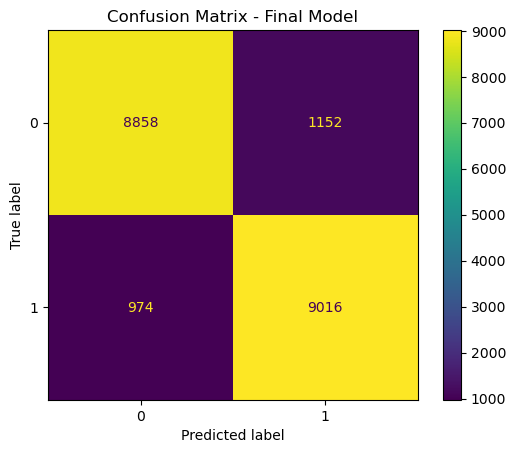

In [18]:
labels_sorted = sorted(np.unique(y_test))
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=labels_sorted
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_sorted
)

disp.plot()
plt.title("Confusion Matrix - Final Model")
plt.show()

## 8. הצגת preprocessing על 3 דוגמאות מה-Test

אותו תהליך preprocessing שהוגדר עבור נתוני ה-Train מופעל גם על נתוני ה-Test באמצעות ה-Pipeline.

בשלב זה מוצגות 3 דוגמאות מתוך נתוני הבדיקה לפני ואחרי הניקוי, כדי להמחיש שהעיבוד מתבצע באותו אופן גם על נתונים חדשים.

In [19]:
for i in range(3):
    raw = X_test.iloc[i]
    cleaned = clean_text(raw)

    print(f"\nTEST EXAMPLE {i+1}")
    print("Original :", raw[:500])
    print("Processed:", cleaned[:500])
    print("Actual   :", y_test.iloc[i])
    print("Predicted:", test_predictions[i])


TEST EXAMPLE 1
Original : This movie makes me want to throw up every time I see it. If you take the first movie, and reverse the plot (ariel wants to leave the sea, her daughter wants to go to the sea), take the same characters and give them new animals and new names, and then throw in crappy animation and the biggest suck factor, possible, you get the little mermaid 2. Its basically a copy of the first movie with a reversed plot. I'll take you through the horror of it step by step. These are the people from the 1st movi
Processed: this movie makes me want to throw up every time i see it if you take the first movie and reverse the plot ariel wants to leave the sea her daughter wants to go to the sea take the same characters and give them new animals and new names and then throw in crappy animation and the biggest suck factor possible you get the little mermaid its basically a copy of the first movie with a reversed plot i'll take you through the horror of it step by step these are the

## Logistic Regression

Logistic Regression הוא אלגוריתם סיווג שמחשב את ההסתברות של דוגמה להשתייך לכל אחת מהמחלקות על בסיס המאפיינים שלה.

במקרה זה המאפיינים הם ערכי ה-TF-IDF של המילים והביטויים בביקורת. במהלך האימון המודל לומד אילו מאפיינים קשורים יותר לכל מחלקה, ובהתאם לכך מבצע חיזוי עבור טקסט חדש.

הפרמטר `C` שולט בעוצמת הרגולריזציה. בדיקה של מספר ערכי `C` מאפשרת למצוא איזון מתאים בין התאמה לנתוני האימון לבין יכולת הכללה על נתונים חדשים.

In [20]:
tfidf = best_model.named_steps["tfidf"]
classifier = best_model.named_steps["classifier"]

feature_names = np.array(tfidf.get_feature_names_out())
classes = classifier.classes_

if len(classes) == 2:
    coefficients = classifier.coef_[0]

    top_positive_idx = np.argsort(coefficients)[-20:][::-1]
    top_negative_idx = np.argsort(coefficients)[:20]

    important_features = pd.DataFrame({
        f"Top Features for class {classes[1]}": feature_names[top_positive_idx],
        "Weight": coefficients[top_positive_idx],
        f"Top Features for class {classes[0]}": feature_names[top_negative_idx],
        "Negative Weight": coefficients[top_negative_idx]
    })

    display(important_features)

else:
    for class_index, class_label in enumerate(classes):
        coefficients = classifier.coef_[class_index]
        top_idx = np.argsort(coefficients)[-15:][::-1]

        class_features = pd.DataFrame({
            "Feature": feature_names[top_idx],
            "Weight": coefficients[top_idx]
        })

        print(f"\nTop features for class {class_label}")
        display(class_features)

,Top Features for class 1,Weight,Top Features for class 0,Negative Weight
0,great,7.600729,worst,-8.583417
1,excellent,7.006865,awful,-7.837472
2,amazing,5.158946,bad,-7.367211
3,perfect,4.916132,the worst,-7.223269
4,wonderful,4.841159,boring,-6.779243
5,fun,4.609509,waste,-6.108376
6,brilliant,4.492708,terrible,-5.975520
7,best,4.380735,poor,-5.925090
8,hilarious,4.086924,dull,-5.621397
9,love,3.893254,horrible,-5.391017
